# Project 5  

**Course:** CIVE 202 - Spring 2026

**Client:** Nebraska Department of Transportation

**Group:** 1

**Date:** N/A - intial Draft(s)

---

# Table of Contents
**Import Packages:**

**Module A: Aggregate Gradation**

**Module B: Volumetric Properties Calculator**

**Module C: IDEAL-CT**

**Module D: Rutting Analyzer**

**Code Summary**

## Important Packages

In [28]:
import pandas as pd    #Needed to read excel files
import numpy as np   #Needed for math operations
import matplotlib.pyplot as plt   #Needed for graph plots that this code will generate


## Module A: Aggregate Gradation

   Sieve Size  3/4 Qtz Chips  3/8 Down Qtz  Qtz Man Sand  Akron Sand     RAP  \
0       19.00          90.71        100.00        100.00      100.00  100.00   
1       12.50          31.02         99.99         99.99      100.00   92.83   
2        9.50          11.66         99.96         99.97      100.00   86.77   
3        4.75           0.57         81.58         98.25       97.13   69.58   
4        2.36           0.43         57.05         74.16       84.17   53.72   
5        1.18           0.42         41.31         48.66       62.62   38.47   
6        0.60           0.42         31.87         31.78       30.40   25.01   
7        0.30           0.40         22.32         15.75        6.68   13.75   
8        0.08           0.36         11.73          4.39        0.47    7.52   
9        0.02           0.26          5.03          1.17        0.08    4.63   

   Combined  
0     98.42  
1     86.48  
2     81.66  
3     71.36  
4     54.44  
5     37.98  
6     24.64  
7     1

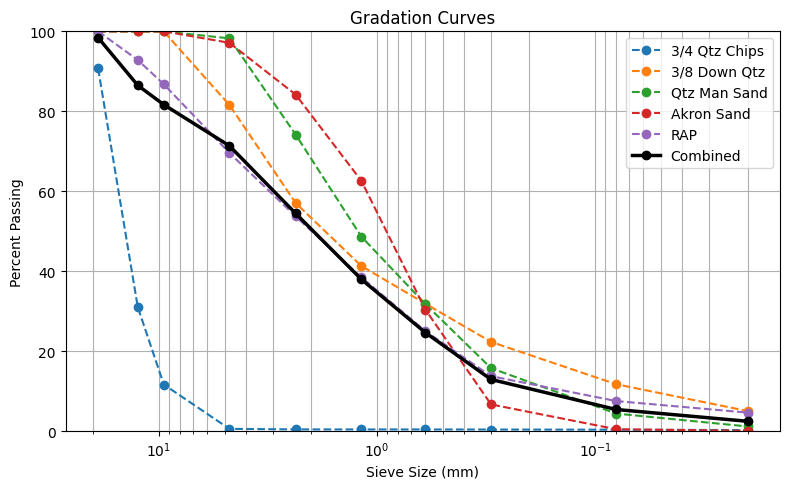

In [29]:


# -----------------------------
# READ FILE
# -----------------------------
df = pd.read_excel("AutoBMD.xlsx", header=None)     # header=None tells the pandas package that there are no column headers in the file

# -----------------------------
# EXTRACT DATA - LEARNED FROM PROJECT 1
# -----------------------------
sieve_sizes = df.iloc[3, 4:14]      # Extracts sieve sizes from row 3, columns 4–13

# Creates a "dictionary" of materials and where each data set is located based on its corresponding row and columns 4 - 14

materials = {
    "3/4 Qtz Chips": df.iloc[4, 4:14],
    "3/8 Down Qtz": df.iloc[5, 4:14],
    "Qtz Man Sand": df.iloc[6, 4:14],
    "Akron Sand": df.iloc[7, 4:14],
    "RAP": df.iloc[8, 4:14],
}


# Blend percentages from column 3, row 4 through 9
weights = df.iloc[4:9, 3]

# -----------------------------
# CLEAN DATA
# -----------------------------


# Converts everything to string and removes '%' symbols
def clean(row):
    row = row.astype(str).str.replace('%','')
# Converts cleaned strings to numbers
# errors='coerce' → invalid values become NaN
    return pd.to_numeric(row, errors='coerce')


# Applies cleaning function to each material dataset
for key in materials:
    materials[key] = clean(materials[key])


# -----------------------------
# SCALE FOR Y AXIS
# -----------------------------
for key in materials:
    if materials[key].max() <= 1.5:   # detects 0–1 data
        materials[key] = materials[key] * 100


# -----------------------------
# REVERSE ORDER FOR X - AXIS
# -----------------------------
# Converts sieve sizes to numeric values
sieve_sizes = pd.to_numeric(sieve_sizes, errors="coerce")

# Swaps the last two sieve sizes to correct ordering issue in Excel
sieve_sizes.iloc[-2], sieve_sizes.iloc[-1] = sieve_sizes.iloc[-1], sieve_sizes.iloc[-2]


# -----------------------------
# CLEAN WEIGHTS
# -----------------------------

# Removes '%' symbols from weights
weights = weights.astype(str).str.replace('%','')

# Converts to decimal (For example, 25% to 0.25)
weights = pd.to_numeric(weights, errors='coerce') / 100

# Normalizes weights so they sum to 1 (important for weighted average)
weights = weights / weights.sum()



# -----------------------------
# COMPUTE COMBINED
# -----------------------------

# Converts materials dictionary into DataFrame and transposes:
# rows = materials, columns = sieve sizes
agg_matrix = pd.DataFrame(materials).T

# Multiplies each material by its weight and sums across rows
# → produces combined gradation curve
combined = (agg_matrix * weights.values[:, None]).sum(axis=0)



# -----------------------------
# BUILD DATAFRAME
# -----------------------------

# Creates a new DataFrame starting with sieve sizes
plot_df = pd.DataFrame({"Sieve Size": sieve_sizes})

# Adds each material's percent passing data as a column
for name in materials:
    plot_df[name] = materials[name].values

# Adds the combined gradation as a new column
plot_df["Combined"] = combined.values



# -----------------------------
# SORT ( going from coarse to fine aggregates)
# -----------------------------

# Sorts sieve sizes from largest to smallest (standard gradation format)
plot_df = plot_df.sort_values(by="Sieve Size", ascending=False).reset_index(drop=True)


plot_df = plot_df.round(2)

print(plot_df)



# -----------------------------
# PLOT - LEARNED FROM PROJECT 3
# -----------------------------
plt.figure(figsize=(8,5))

for name in materials:
    plt.plot(plot_df["Sieve Size"], plot_df[name],
             marker='o', linestyle='--', label=name)

plt.plot(plot_df["Sieve Size"], plot_df["Combined"],
         color='black', linewidth=2.5, marker='o', label='Combined')

# Crucial for gradation analysis
plt.xscale('log')
plt.gca().invert_xaxis()
plt.ylim(0, 100)

plt.xlabel("Sieve Size (mm)")
plt.ylabel("Percent Passing")
plt.title("Gradation Curves")

plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

## Module B: Volumetric Properties Calculator

In [30]:
# =========================
# Module B: Volumetric Properties Calculator
# Client: :contentReference[oaicite:0]{index=0}
# =========================

import pandas as pd

def volumetric_properties_calculator(file_path):
    """
    Reads the Volumetrics tab from AutoBMD.xlsx
    Calculates:
        - Final Gmm
        - Final Gmb
        - Air Voids (Va)
    Flags samples if Air Voids are not between 6.5% and 7.5%
    """

    # Read Volumetrics sheet
    df = pd.read_excel(file_path, sheet_name="Volumetrics", header=None)

    # Extract actual sample data rows (starting from row index 2)
    samples = []

    for i in range(2, len(df)):
        sample = df.iloc[i, 1]

        if pd.isna(sample):
            continue

        # -------------------------
        # GMM Calculation
        # -------------------------
        bowl_air = df.iloc[i, 2]
        bowl_sub = df.iloc[i, 3]
        bowl_mix_air = df.iloc[i, 4]
        bowl_mix_sub = df.iloc[i, 5]

        # Formula:
        # Gmm = (Bowl + Mix air - Bowl air) /
        #       [(Bowl + Mix air - Bowl air) - (Bowl + Mix submerged - Bowl submerged)]

        mix_mass_air = bowl_mix_air - bowl_air
        mix_mass_sub = bowl_mix_sub - bowl_sub

        final_gmm = mix_mass_air / (mix_mass_air - mix_mass_sub)

        # -------------------------
        # GMB Calculation
        # -------------------------
        dry_mass = df.iloc[i, 7]
        submerged_mass = df.iloc[i, 8]
        ssd_mass = df.iloc[i, 9]

        # Formula:
        # Gmb = Dry Mass / (SSD Mass - Submerged Mass)

        final_gmb = dry_mass / (ssd_mass - submerged_mass)

        # -------------------------
        # Air Voids Calculation
        # -------------------------
        # Va = ((Gmm - Gmb) / Gmm) * 100

        air_voids = ((final_gmm - final_gmb) / final_gmm) * 100

        # -------------------------
        # QC Check
        # -------------------------
        if 6.5 <= air_voids <= 7.5:
            status = "Valid for Performance Testing"
        else:
            status = "Invalid for Performance Testing"

        samples.append({
            "Sample": sample,
            "Final Gmm": round(final_gmm, 3),
            "Final Gmb": round(final_gmb, 3),
            "Air Voids (%)": round(air_voids, 2),
            "Status": status
        })

    # Create summary table
    results_df = pd.DataFrame(samples)

    print("\n===== Volumetric Properties Summary =====\n")
    print(results_df.to_string(index=False))

    return results_df


# -------------------------
# Run Module B
# -------------------------

file_path = "AutoBMD.xlsx"

results = volumetric_properties_calculator(file_path)


===== Volumetric Properties Summary =====

 Sample  Final Gmm  Final Gmb  Air Voids (%)                          Status
      1      2.418      2.241           7.29   Valid for Performance Testing
      2        NaN      2.251            NaN Invalid for Performance Testing
      3        NaN      2.249            NaN Invalid for Performance Testing


## Module C: IDEAL-CT

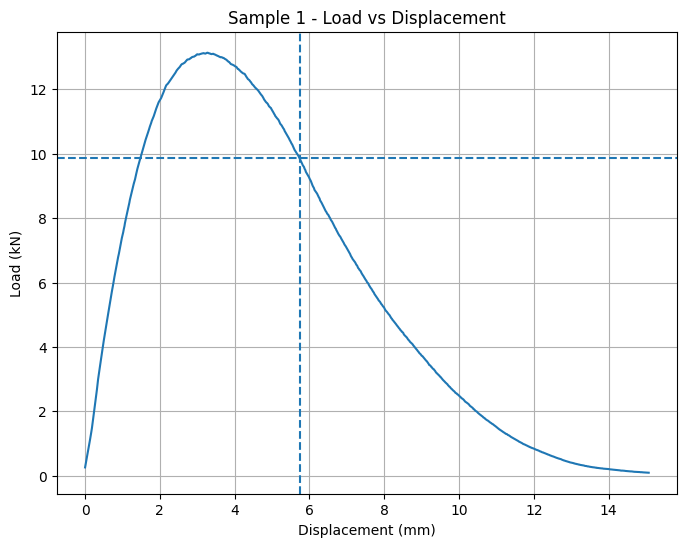

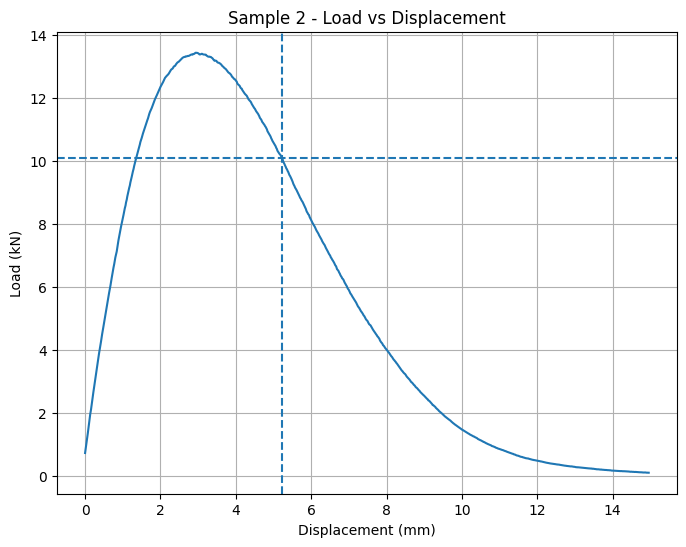

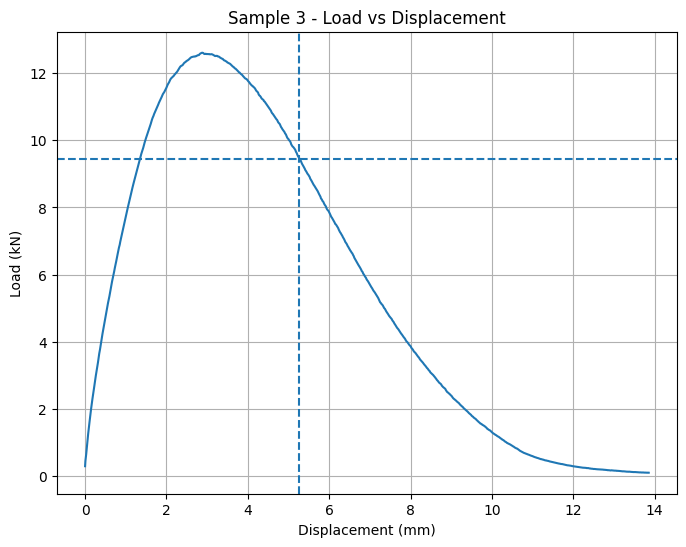


===== IDEAL-CT Summary =====

  Sample  Peak Load  Area Under Curve  75% Peak Load   l75    m75  CTIndex
Sample 1     13.139            87.778          9.854 5.737 -2.056    0.003
Sample 2     13.447            82.058         10.085 5.224 -2.722    0.005
Sample 3     12.612            76.963          9.459 5.267 -1.882    0.003


In [31]:
# =========================
# Module C: IDEAL-CT Analyzer (Fixed Version)
# Client: :contentReference[oaicite:0]{index=0}
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def ideal_ct_analyzer(file_path):
    """
    Reads IDEAL-CT sheet from AutoBMD.xlsx

    Calculates:
        - Area under the curve
        - Peak Load
        - 75% Peak Load
        - Post-peak slope at 75% peak load
        - Displacement at 75% peak load
        - CTIndex

    Outputs:
        - Load vs Displacement plot
        - CTIndex summary table
    """

    # Read IDEAL-CT sheet
    df = pd.read_excel(file_path, sheet_name="IDEAL-CT", header=None)

    results = []

    # Sample columns setup
    # Adjust if your Excel columns are different
    sample_columns = [
        ("Sample 1", 1, 2),
        ("Sample 2", 4, 5),
        ("Sample 3", 7, 8)
    ]

    # Constants
    t = 61.91   # specimen thickness (mm)
    D = 150     # specimen diameter (mm)

    for sample_name, load_col, disp_col in sample_columns:

        # Extract sample data
        sample_data = df.iloc[2:, [load_col, disp_col]].copy()
        sample_data.columns = ["Load", "Displacement"]

        sample_data = sample_data.apply(pd.to_numeric, errors="coerce")
        sample_data = sample_data.dropna()

        if sample_data.empty:
            print(f"{sample_name}: No valid data found.")
            continue

        load = sample_data["Load"].values
        displacement = sample_data["Displacement"].values

        # -------------------------
        # 1. Area Under Curve
        # FIXED HERE
        # -------------------------
        area = np.trapezoid(load, displacement)

        # -------------------------
        # 2. Peak Load
        # -------------------------
        peak_load = np.max(load)
        peak_index = np.argmax(load)

        # -------------------------
        # 3. 75% Peak Load
        # -------------------------
        load_75 = 0.75 * peak_load

        # Post-peak region only
        post_peak_load = load[peak_index:]
        post_peak_disp = displacement[peak_index:]

        # Find closest point to 75% peak load
        idx_75 = np.argmin(np.abs(post_peak_load - load_75))

        l75 = post_peak_disp[idx_75]

        # -------------------------
        # 4. Post-Peak Slope (m75)
        # -------------------------
        if idx_75 < len(post_peak_load) - 1:
            x1 = post_peak_disp[idx_75]
            x2 = post_peak_disp[idx_75 + 1]
            y1 = post_peak_load[idx_75]
            y2 = post_peak_load[idx_75 + 1]

            if (x2 - x1) != 0:
                m75 = (y2 - y1) / (x2 - x1)
            else:
                m75 = np.nan
        else:
            m75 = np.nan

        # -------------------------
        # 5. CTIndex Calculation
        # -------------------------
        if pd.notna(m75) and m75 != 0 and l75 != 0:
            CTIndex = (area / (t * D)) * (abs(m75) / l75)
        else:
            CTIndex = np.nan

        # -------------------------
        # Plot
        # -------------------------
        plt.figure(figsize=(8, 6))
        plt.plot(displacement, load)

        plt.axhline(load_75, linestyle="--")
        plt.axvline(l75, linestyle="--")

        plt.title(f"{sample_name} - Load vs Displacement")
        plt.xlabel("Displacement (mm)")
        plt.ylabel("Load (kN)")
        plt.grid(True)
        plt.show()

        # -------------------------
        # Save Results
        # -------------------------
        results.append({
            "Sample": sample_name,
            "Peak Load": round(peak_load, 3),
            "Area Under Curve": round(area, 3),
            "75% Peak Load": round(load_75, 3),
            "l75": round(l75, 3),
            "m75": round(m75, 3) if pd.notna(m75) else "N/A",
            "CTIndex": round(CTIndex, 3) if pd.notna(CTIndex) else "N/A"
        })

    # Final Results Table
    results_df = pd.DataFrame(results)

    print("\n===== IDEAL-CT Summary =====\n")
    print(results_df.to_string(index=False))

    return results_df


# -------------------------
# Run Module C
# -------------------------

file_path = "AutoBMD.xlsx"

results = ideal_ct_analyzer(file_path)

## Module D: Rutting Analyzer

HWTT Sheet Shape: (10002, 6)
Detected Samples: [('Sample 1', 0, 1), ('Sample 2', 2, 3), ('Sample 3', 4, 5)]
Sample 1: No valid data found
Sample 2: No valid data found


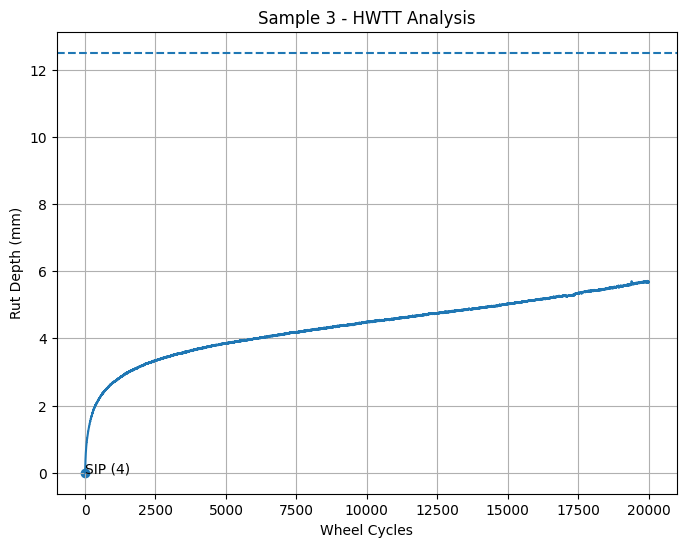


========== HWTT SUMMARY ==========

  Sample  SIP Cycle  SIP Rut Depth Failure Cycle Pass/Fail
Sample 3          4            0.0  Did Not Fail      PASS


In [32]:
# =========================
# Module D: HWTT Rutting Analyzer
# AUTO-FIXED VERSION (No Column Index Errors)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def hwtt_rutting_analyzer(file_path):
    """
    Module D:
    - Detect SIP (Stripping Inflection Point)
    - Detect Failure Point at 12.5 mm
    - Determine PASS / FAIL based on surviving 20,000 cycles
    - Automatically handles available columns in HWTT sheet
    """

    # Read HWTT sheet
    df = pd.read_excel(file_path, sheet_name="HWTT", header=None)

    print("HWTT Sheet Shape:", df.shape)

    results = []

    # -----------------------------------
    # AUTO-DETECT SAMPLE COLUMN PAIRS
    # Uses every 2 columns as:
    # Cycles | Rut Depth
    # -----------------------------------
    total_cols = df.shape[1]

    sample_columns = []
    sample_num = 1

    for col in range(0, total_cols - 1, 2):
        sample_columns.append(
            (f"Sample {sample_num}", col, col + 1)
        )
        sample_num += 1

    print("Detected Samples:", sample_columns)

    # -----------------------------------
    # Process Each Sample
    # -----------------------------------
    for sample_name, cycle_col, rut_col in sample_columns:

        try:
            sample_data = df.iloc[2:, [cycle_col, rut_col]].copy()
            sample_data.columns = ["Cycles", "RutDepth"]

            sample_data = sample_data.apply(
                pd.to_numeric,
                errors="coerce"
            )

            sample_data = sample_data.dropna()

            if sample_data.empty:
                print(f"{sample_name}: No valid data found")
                continue

            cycles = sample_data["Cycles"].to_numpy()
            rut_depth = sample_data["RutDepth"].to_numpy()

            # -----------------------------------
            # SIP Detection
            # -----------------------------------
            sip_cycle = "N/A"
            sip_rut = "N/A"

            if len(cycles) > 2:
                slopes = np.diff(rut_depth) / np.diff(cycles)

                if len(slopes) > 1:
                    slope_change = np.diff(slopes)

                    if len(slope_change) > 0:
                        sip_index = np.argmax(slope_change) + 1
                        sip_cycle = int(cycles[sip_index])
                        sip_rut = round(float(rut_depth[sip_index]), 3)

            # -----------------------------------
            # Failure Detection
            # -----------------------------------
            fail_cycle = "Did Not Fail"
            status = "PASS"

            for i in range(len(rut_depth)):
                if rut_depth[i] >= 12.5:
                    fail_cycle = int(cycles[i])

                    if fail_cycle < 20000:
                        status = "FAIL"
                    else:
                        status = "PASS"

                    break

            # -----------------------------------
            # Plot
            # -----------------------------------
            plt.figure(figsize=(8, 6))
            plt.plot(cycles, rut_depth)

            # SIP marker
            if sip_cycle != "N/A":
                plt.scatter(sip_cycle, sip_rut)
                plt.annotate(
                    f"SIP ({sip_cycle})",
                    (sip_cycle, sip_rut)
                )

            # Failure marker
            if fail_cycle != "Did Not Fail":
                plt.scatter(fail_cycle, 12.5)
                plt.annotate(
                    f"Failure ({fail_cycle})",
                    (fail_cycle, 12.5)
                )

            # Threshold line
            plt.axhline(12.5, linestyle="--")

            plt.title(f"{sample_name} - HWTT Analysis")
            plt.xlabel("Wheel Cycles")
            plt.ylabel("Rut Depth (mm)")
            plt.grid(True)
            plt.show()

            # -----------------------------------
            # Save Results
            # -----------------------------------
            results.append({
                "Sample": sample_name,
                "SIP Cycle": sip_cycle,
                "SIP Rut Depth": sip_rut,
                "Failure Cycle": fail_cycle,
                "Pass/Fail": status
            })

        except Exception as e:
            print(f"{sample_name} skipped due to error: {e}")

    # -----------------------------------
    # Final Summary Table
    # -----------------------------------
    results_df = pd.DataFrame(results)

    print("\n========== HWTT SUMMARY ==========\n")

    if not results_df.empty:
        print(results_df.to_string(index=False))
    else:
        print("No results generated. Check HWTT sheet format.")

    return results_df


# -----------------------------------
# Run Module D
# -----------------------------------

file_path = "AutoBMD.xlsx"

results = hwtt_rutting_analyzer(file_path)

## Code Summary 

   Sieve Size  3/4 Qtz Chips  3/8 Down Qtz  Qtz Man Sand  Akron Sand     RAP  \
0       19.00          90.71        100.00        100.00      100.00  100.00   
1       12.50          31.02         99.99         99.99      100.00   92.83   
2        9.50          11.66         99.96         99.97      100.00   86.77   
3        4.75           0.57         81.58         98.25       97.13   69.58   
4        2.36           0.43         57.05         74.16       84.17   53.72   
5        1.18           0.42         41.31         48.66       62.62   38.47   
6        0.60           0.42         31.87         31.78       30.40   25.01   
7        0.30           0.40         22.32         15.75        6.68   13.75   
8        0.08           0.36         11.73          4.39        0.47    7.52   
9        0.02           0.26          5.03          1.17        0.08    4.63   

   Combined  
0     98.42  
1     86.48  
2     81.66  
3     71.36  
4     54.44  
5     37.98  
6     24.64  
7     1

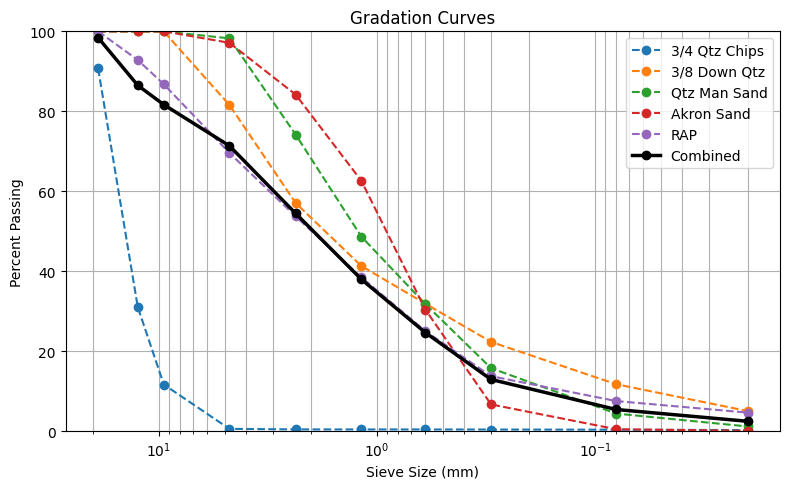


========== MODULE B: Volumetrics ==========
 Sample  Final Gmm  Final Gmb  Air Voids (%)                          Status
      1      2.418      2.241           7.29   Valid for Performance Testing
      2        NaN      2.251            NaN Invalid for Performance Testing
      3        NaN      2.249            NaN Invalid for Performance Testing

========== MODULE C: IDEAL-CT ==========


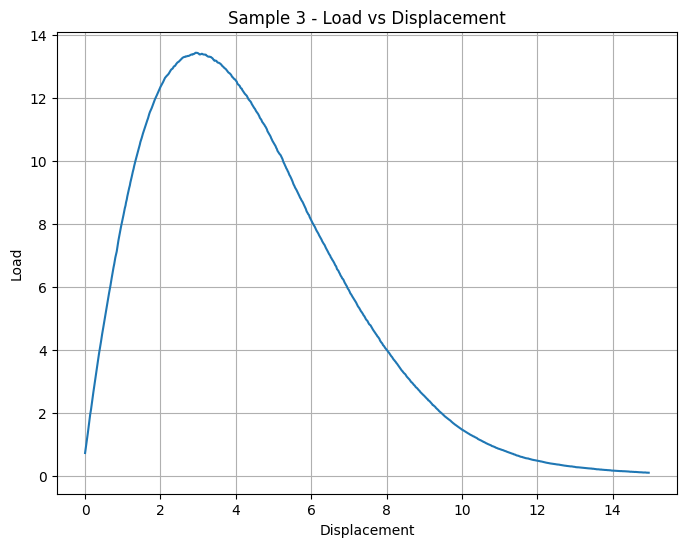

  Sample  CTIndex
Sample 3    42.76

========== MODULE D: HWTT ==========


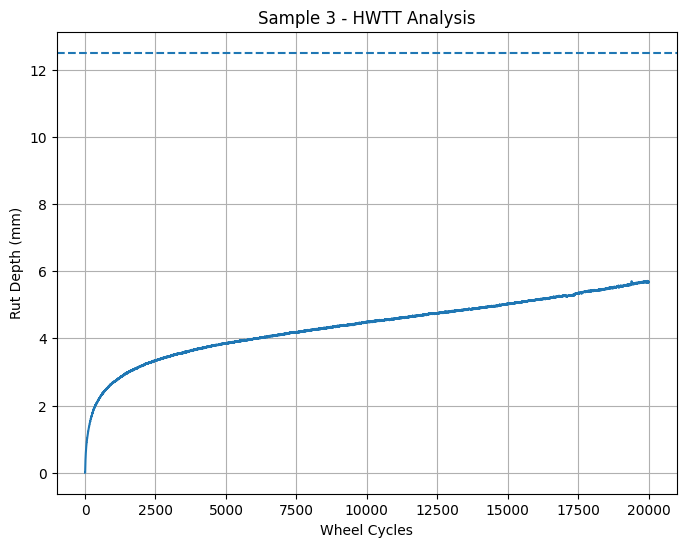

  Sample  SIP Cycle Failure Cycle Pass/Fail
Sample 3          4  Did Not Fail      PASS


In [33]:
# =====================================================
# Auto-BMD Final Project
# Client: Nebraska Department of Transportation (NDOT)
# CIVE 202 - Project 5
# =====================================================
# This file runs all four required modules sequentially:
# Module A - Aggregate Gradation Automator
# Module B - Volumetric Properties Calculator
# Module C - IDEAL-CT Analyzer
# Module D - HWTT Rutting Analyzer
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "AutoBMD.xlsx"


# =====================================================
# MODULE A - Aggregate Gradation Automator
# =====================================================

# -----------------------------
# READ FILE
# -----------------------------
df = pd.read_excel("AutoBMD.xlsx", header=None)

# -----------------------------
# EXTRACT DATA
# -----------------------------
sieve_sizes = df.iloc[3, 4:14]

materials = {
    "3/4 Qtz Chips": df.iloc[4, 4:14],
    "3/8 Down Qtz": df.iloc[5, 4:14],
    "Qtz Man Sand": df.iloc[6, 4:14],
    "Akron Sand": df.iloc[7, 4:14],
    "RAP": df.iloc[8, 4:14],
}

weights = df.iloc[4:9, 3]

# -----------------------------
# CLEAN DATA
# -----------------------------
def clean(row):
    row = row.astype(str).str.replace('%', '')
    return pd.to_numeric(row, errors='coerce')

for key in materials:
    materials[key] = clean(materials[key])

# -----------------------------
# SCALE FOR Y AXIS
# -----------------------------
for key in materials:
    if materials[key].max() <= 1.5:
        materials[key] = materials[key] * 100

# -----------------------------
# REVERSE ORDER FOR X AXIS
# -----------------------------
sieve_sizes = pd.to_numeric(sieve_sizes, errors="coerce")
sieve_sizes.iloc[-2], sieve_sizes.iloc[-1] = sieve_sizes.iloc[-1], sieve_sizes.iloc[-2]

# -----------------------------
# CLEAN WEIGHTS
# -----------------------------
weights = weights.astype(str).str.replace('%', '')
weights = pd.to_numeric(weights, errors='coerce') / 100
weights = weights / weights.sum()

# -----------------------------
# COMPUTE COMBINED
# -----------------------------
agg_matrix = pd.DataFrame(materials).T
combined = (agg_matrix * weights.values[:, None]).sum(axis=0)

# -----------------------------
# BUILD DATAFRAME
# -----------------------------
plot_df = pd.DataFrame({"Sieve Size": sieve_sizes})

for name in materials:
    plot_df[name] = materials[name].values

plot_df["Combined"] = combined.values

# -----------------------------
# SORT
# -----------------------------
plot_df = plot_df.sort_values(
    by="Sieve Size",
    ascending=False
).reset_index(drop=True)

plot_df = plot_df.round(2)

print(plot_df)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(8, 5))

for name in materials:
    plt.plot(
        plot_df["Sieve Size"],
        plot_df[name],
        marker='o',
        linestyle='--',
        label=name
    )

plt.plot(
    plot_df["Sieve Size"],
    plot_df["Combined"],
    color='black',
    linewidth=2.5,
    marker='o',
    label='Combined'
)

plt.xscale('log')
plt.gca().invert_xaxis()
plt.ylim(0, 100)

plt.xlabel("Sieve Size (mm)")
plt.ylabel("Percent Passing")
plt.title("Gradation Curves")

plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()


# =====================================================
# MODULE B - Volumetric Properties Calculator
# =====================================================
def module_b(file_path):
    print("\n========== MODULE B: Volumetrics ==========")

    try:
        df = pd.read_excel(
            file_path,
            sheet_name="Volumetrics",
            header=None
        )

        results = []

        for i in range(2, len(df)):
            sample = df.iloc[i, 1]

            if pd.isna(sample):
                continue

            bowl_air = df.iloc[i, 2]
            bowl_sub = df.iloc[i, 3]
            bowl_mix_air = df.iloc[i, 4]
            bowl_mix_sub = df.iloc[i, 5]

            dry_mass = df.iloc[i, 7]
            submerged_mass = df.iloc[i, 8]
            ssd_mass = df.iloc[i, 9]

            mix_mass_air = bowl_mix_air - bowl_air
            mix_mass_sub = bowl_mix_sub - bowl_sub

            gmm = mix_mass_air / (mix_mass_air - mix_mass_sub)
            gmb = dry_mass / (ssd_mass - submerged_mass)
            air_voids = ((gmm - gmb) / gmm) * 100

            status = (
                "Valid for Performance Testing"
                if 6.5 <= air_voids <= 7.5
                else "Invalid for Performance Testing"
            )

            results.append({
                "Sample": sample,
                "Final Gmm": round(gmm, 3),
                "Final Gmb": round(gmb, 3),
                "Air Voids (%)": round(air_voids, 2),
                "Status": status
            })

        results_df = pd.DataFrame(results)
        print(results_df.to_string(index=False))

    except Exception as e:
        print(f"Module B issue: {e}")


# =====================================================
# MODULE C - IDEAL-CT Analyzer
# =====================================================
def module_c(file_path):
    print("\n========== MODULE C: IDEAL-CT ==========")

    try:
        df = pd.read_excel(
            file_path,
            sheet_name="IDEAL-CT",
            header=None
        )

        total_cols = df.shape[1]
        results = []
        sample_num = 1

        for col in range(0, total_cols - 1, 2):
            sample_name = f"Sample {sample_num}"

            sample_data = df.iloc[2:, [col, col + 1]].copy()
            sample_data.columns = ["Load", "Displacement"]

            sample_data = sample_data.apply(
                pd.to_numeric,
                errors="coerce"
            ).dropna()

            if sample_data.empty:
                sample_num += 1
                continue

            load = sample_data["Load"].to_numpy()
            displacement = sample_data["Displacement"].to_numpy()

            area = np.trapezoid(load, displacement)
            peak_load = np.max(load)
            peak_index = np.argmax(load)
            load_75 = 0.75 * peak_load

            post_load = load[peak_index:]
            post_disp = displacement[peak_index:]

            idx_75 = np.argmin(
                np.abs(post_load - load_75)
            )

            l75 = post_disp[idx_75]

            if idx_75 < len(post_load) - 1:
                x1 = post_disp[idx_75]
                x2 = post_disp[idx_75 + 1]
                y1 = post_load[idx_75]
                y2 = post_load[idx_75 + 1]

                m75 = (
                    (y2 - y1) / (x2 - x1)
                    if (x2 - x1) != 0
                    else np.nan
                )
            else:
                m75 = np.nan

            ctindex = (
                round((area * abs(m75)) / l75, 3)
                if pd.notna(m75) and l75 != 0
                else "N/A"
            )

            plt.figure(figsize=(8, 6))
            plt.plot(displacement, load)

            plt.title(
                f"{sample_name} - Load vs Displacement"
            )
            plt.xlabel("Displacement")
            plt.ylabel("Load")
            plt.grid(True)
            plt.show()

            results.append({
                "Sample": sample_name,
                "CTIndex": ctindex
            })

            sample_num += 1

        print(pd.DataFrame(results).to_string(index=False))

    except Exception as e:
        print(f"Module C issue: {e}")


# =====================================================
# MODULE D - HWTT Rutting Analyzer
# =====================================================
def module_d(file_path):
    print("\n========== MODULE D: HWTT ==========")

    try:
        df = pd.read_excel(
            file_path,
            sheet_name="HWTT",
            header=None
        )

        results = []
        total_cols = df.shape[1]
        sample_num = 1

        for col in range(0, total_cols - 1, 2):
            sample_name = f"Sample {sample_num}"

            sample_data = df.iloc[2:, [col, col + 1]].copy()
            sample_data.columns = ["Cycles", "RutDepth"]

            sample_data = sample_data.apply(
                pd.to_numeric,
                errors="coerce"
            ).dropna()

            if sample_data.empty:
                sample_num += 1
                continue

            cycles = sample_data["Cycles"].to_numpy()
            rut = sample_data["RutDepth"].to_numpy()

            sip_cycle = "N/A"

            if len(cycles) > 2:
                slopes = np.diff(rut) / np.diff(cycles)

                if len(slopes) > 1:
                    sip_idx = np.argmax(np.diff(slopes)) + 1
                    sip_cycle = int(cycles[sip_idx])

            fail_cycle = "Did Not Fail"
            status = "PASS"

            for i in range(len(rut)):
                if rut[i] >= 12.5:
                    fail_cycle = int(cycles[i])
                    status = (
                        "FAIL"
                        if fail_cycle < 20000
                        else "PASS"
                    )
                    break

            plt.figure(figsize=(8, 6))
            plt.plot(cycles, rut)
            plt.axhline(12.5, linestyle='--')

            plt.title(
                f"{sample_name} - HWTT Analysis"
            )
            plt.xlabel("Wheel Cycles")
            plt.ylabel("Rut Depth (mm)")
            plt.grid(True)
            plt.show()

            results.append({
                "Sample": sample_name,
                "SIP Cycle": sip_cycle,
                "Failure Cycle": fail_cycle,
                "Pass/Fail": status
            })

            sample_num += 1

        print(pd.DataFrame(results).to_string(index=False))

    except Exception as e:
        print(f"Module D issue: {e}")


# =====================================================
# RUN ALL MODULES SEQUENTIALLY
# =====================================================
if __name__ == "__main__":
    module_b(FILE_PATH)
    module_c(FILE_PATH)
    module_d(FILE_PATH)


# =====================================================
# USER GUIDE
# =====================================================
# 1. Keep the Excel file name as: AutoBMD.xlsx
# 2. Do not change sheet names:
#    - Volumetrics
#    - IDEAL-CT
#    - HWTT
# 3. Do not insert blank rows inside datasets
# 4. Keep columns in the same order used by the original file
# 5. Keep units unchanged
# 6. Save the Excel file in the same folder as this Python file
# 7. Run this file to process all modules automatically
# =====================================================